# Strategy analysis: expectancy, edge and risk

        Compare every strategy in `data/raw/strategy_report`, then open its linked notebook for return and drawdown by day. Run all cells with the **Python from the visualizer conda environment** kernel. All money amounts are INR; exported fractions use `0.01 = 1%`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_project_root():
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / "src" / "visualizer" / "strategy_analysis.py").is_file():
            return path
    raise FileNotFoundError("Start Jupyter inside the visualizer repository")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from visualizer.strategy_analysis import (
    load_strategies, comparison_table, strategy_summary, expectancy_stats,
    monthly_table, drawdown_episodes, SimulationConfig, strategy_risk_scenarios,
    risk_win_matrix, SCREENSHOT_REFERENCE, position_size,
)
from visualizer.strategy_charts import (
    expectancy_chart, equity_comparison, equity_small_multiples, heatmap,
    daily_chart, elapsed_day_chart, trade_diagnostics, monthly_chart,
)

get_ipython().run_line_magic("matplotlib", "inline")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show_table(frame):
    """Keep exported data numeric; format fractions only for notebook display."""
    percentage_columns = {
        "win_rate", "loss_rate", "total_return", "risk_coverage", "risk_fraction_coverage", "max_trade_drawdown",
        "max_daily_drawdown", "median_risk_fraction", "p95_risk_fraction", "max_risk_fraction",
        "return_fraction", "worst_daily_drawdown", "drawdown_fraction", "risk_fraction",
        "realized_loss_fraction", "success_probability", "drawdown_breach_probability",
        "timeout_probability", "monte_carlo_se",
    }
    fmt = {col: "{:.2%}" if col in percentage_columns else "{:,.2f}"
           for col in frame.select_dtypes(include="number").columns}
    display(frame.style.format(fmt, na_rep="N/A"))

In [2]:
# Editable scenario, not the unknown assumptions behind the screenshot.
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "strategy_report"
SIMULATION = SimulationConfig(
    target_return=0.10,     # reach +10% of starting simulated equity
    max_drawdown=0.10,     # stop at a 10% fall from the running equity peak
    horizon_trades=100,
    paths=5000,
    seed=42,
)
EXPORT = True
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "strategy_analysis"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "strategy"
if EXPORT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

strategies = load_strategies(RAW_DIR)  # reads ZIP members directly; no extraction needed
summary = comparison_table(strategies)
print(f"Loaded {len(strategies)} strategies from {RAW_DIR}")

Loaded 11 strategies from /home/amit/python/src/github.com/AppsByZubin/visualizer/data/raw/strategy_report


## Definitions and data contract

- **Expectancy (INR/trade)** = win rate × average net win − loss rate × absolute average net loss. Rates use **all closed trades**, including breakevens. A value strictly greater than zero passes the requested acceptance screen. Fees are already included in `net_pnl`; do not deduct them again.
- **Realized equity** = initial cash + cumulative closed-trade net P&L. **Cumulative return** = equity / initial cash − 1. Trade curves are ordered by exit timestamp and start at trade zero. Percentages are account returns, not the sum of individual instrument returns.
- **Drawdown** = equity / running peak − 1, with initial capital included in the peak. Daily return = day's realized net P&L / previous day's realized equity. Trade drawdown can be deeper than end-of-day drawdown.
- **Initial stop risk (INR)** = adverse distance from entry to the **first `PLACE_SL` trigger** × original quantity. **Risk per trade** = initial stop risk / realized equity strictly before entry. A later trailing stop in `order_log.csv` is unsuitable for this calculation. `net_r` = net P&L / initial stop risk. Risk excludes fees and slippage, so a realized loss can exceed 1R. It is not a maximum possible loss.
- Equity excludes unrealized P&L, margin requirements and risk from concurrent open positions. Same-timestamp exits are excluded from equity before entry because their within-second ordering is unknown. Missing, delayed or inconsistent original stops remain unknown instead of being guessed.
- Rows without complete closed outcomes are listed separately. Dates without realized closes are carried forward on the calendar; this does not prove those dates had complete market data. First and last months may be partial. Report periods and trade counts differ across strategies.
- Some source end-of-day exits precede their entry by seconds. These rows retain reported P&L and original-stop R for reconciliation/simulation, but holding time, pre-entry equity and percentage risk are unknown. `chronology_errors` counts these rows; repair the source before relying on intraday execution results. Initial-stop coverage and percentage-risk coverage are shown separately.

The supplied order IDs use `MOCK` and report metadata includes a backtest intrabar policy. Treat these as reported simulated outcomes. Positive historical expectancy is a screening result; independent forward/out-of-sample evidence is needed to assess future payouts.

The 95% expectancy interval resamples **whole active exit days** 5,000 times (seed 42), preserving within-day trade dependence. It assumes independent days and does not account for selecting the best strategy from many trials.

Formula references: [CME: mathematical expectation](https://www.cmegroup.com/education/courses/trading-psychology/the-mathematics-of-trading-success) and [CME: position size from stop distance and account risk](https://www.cmegroup.com/education/courses/trade-and-risk-management/proper-position-size).

## Report inventory and reconciliation
The closed-trade ledger must agree with daily P&L, daily equity, charges and summary totals before comparison.

In [3]:
audit = pd.concat([d.checks.assign(strategy=name) for name, d in strategies.items()], ignore_index=True)
show_table(summary[["trades", "excluded_rows", "chronology_errors", "initial_cash", "start_date", "end_date", "active_days", "reconciled", "risk_coverage", "risk_fraction_coverage"]])
assert audit.passed.all(), audit.loc[~audit.passed].to_string(index=False)
excluded = pd.concat([d.excluded.assign(strategy=name) for name, d in strategies.items()], ignore_index=True)
if not excluded.empty:
    display(Markdown("**Rows excluded from realized performance:**"))
    display(excluded[["strategy", "id", "timestamp", "status", "exclusion_reason"]])
display(Markdown(f"**All {len(audit)} reconciliation checks passed.**"))
chronology_issues = pd.concat([d.trades.loc[~d.trades.chronology_valid].assign(strategy=name) for name, d in strategies.items()], ignore_index=True)
if not chronology_issues.empty:
    display(Markdown("**Source chronology errors (reported P&L retained):**"))
    display(chronology_issues[["strategy", "id", "timestamp", "exit_time", "status", "net_pnl"]])

,trades,excluded_rows,chronology_errors,initial_cash,start_date,end_date,active_days,reconciled,risk_coverage,risk_fraction_coverage
strategy,,,,,,,,,,
bb_vwap_ema_v2,302.00,1.00,1.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,140.00,True,100.00%,99.67%
bb_vwap_ema,381.00,0.00,1.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,150.00,True,100.00%,99.74%
meanrev_vwap,62.00,1.00,0.00,"100,000.00",2025-12-31 00:00:00,2026-09-10 00:00:00,41.00,True,100.00%,100.00%
bb_vwap_ema_v3,315.00,1.00,0.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,140.00,True,100.00%,100.00%
timeseries_trend_v2,422.00,0.00,0.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,147.00,True,100.00%,100.00%
timeseries_trend,352.00,0.00,0.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,152.00,True,100.00%,100.00%
hm_ema_adx_v2,323.00,0.00,4.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,150.00,True,100.00%,98.76%
hm_ema_adx,337.00,0.00,1.00,"100,000.00",2026-01-06 00:00:00,2026-09-11 00:00:00,143.00,True,100.00%,99.70%
timeseries_trend_v3,439.00,0.00,0.00,"100,000.00",2025-12-31 00:00:00,2026-09-11 00:00:00,148.00,True,100.00%,100.00%


**Rows excluded from realized performance:**

,strategy,id,timestamp,status,exclusion_reason
0,bb_vwap_ema_v2,a6c07c06,2026-04-02 11:38:09,OPEN,Open position; no realized outcome
1,bb_vwap_ema_v3,179902e6,2026-04-02 11:38:09,OPEN,Open position; no realized outcome
2,meanrev_vwap,c925491d,2026-04-02 11:35:04,OPEN,Open position; no realized outcome


**All 110 reconciliation checks passed.**

**Source chronology errors (reported P&L retained):**

,strategy,id,timestamp,exit_time,status,net_pnl
0,bb_vwap_ema,c47d6dc7,2026-07-08 15:16:14,2026-07-08 15:15:00,EOD_SQUARE_OFF,-332.1768
1,bb_vwap_ema_v2,bbfb0fd9,2026-07-08 15:16:14,2026-07-08 15:15:00,EOD_SQUARE_OFF,-332.1768
2,hm_ema_adx,01146723,2026-07-06 15:10:30,2026-07-06 15:10:00,EOD_SQUARE_OFF,237.0243
3,hm_ema_adx_v2,ea988c2f,2026-07-09 15:10:30,2026-07-09 15:10:00,EOD_SQUARE_OFF,240.1436
4,hm_ema_adx_v2,9f25d648,2026-08-03 15:10:30,2026-08-03 15:10:00,EOD_SQUARE_OFF,152.2687
5,hm_ema_adx_v2,c627d62c,2026-08-18 15:00:35,2026-08-18 15:00:00,EOD_SQUARE_OFF,-260.2773
6,hm_ema_adx_v2,d8cc7938,2026-09-03 15:00:15,2026-09-03 15:00:00,EOD_SQUARE_OFF,911.8446


## 1. Risk matrix: expectancy acceptance
Accept when **net expectancy > 0**. The confidence interval, drawdown and recent expectancy provide context alongside this rule.

,trades,win_rate,loss_rate,avg_win,avg_loss,expectancy,expectancy_ci_low,expectancy_ci_high,profit_factor,recent_30_expectancy,decision
strategy,,,,,,,,,,,
bb_vwap_ema_v2,302.00,62.91%,37.09%,"6,287.68","4,807.47","2,172.92","1,080.95","3,425.11",2.22,976.08,ACCEPT: positive expectancy
bb_vwap_ema,381.00,73.23%,26.77%,"4,023.98","5,331.71","1,519.31",860.11,"2,208.85",2.06,323.41,ACCEPT: positive expectancy
meanrev_vwap,62.00,70.97%,29.03%,"3,418.85","3,197.13","1,498.08",500.70,"2,461.69",2.61,"1,366.36",ACCEPT: positive expectancy
bb_vwap_ema_v3,315.00,48.89%,51.11%,"5,994.06","3,049.56","1,371.76",591.33,"2,219.12",1.88,831.52,ACCEPT: positive expectancy
timeseries_trend_v2,422.00,45.02%,54.98%,"8,576.07","4,800.31","1,222.23",384.55,"2,148.84",1.46,682.88,ACCEPT: positive expectancy
timeseries_trend,352.00,57.95%,42.05%,"7,275.54","7,275.27","1,157.59",91.14,"2,263.37",1.38,-282.23,ACCEPT: positive expectancy
hm_ema_adx_v2,323.00,54.18%,45.82%,"7,239.48","6,109.28","1,123.02",152.46,"2,148.63",1.40,"1,586.79",ACCEPT: positive expectancy
hm_ema_adx,337.00,48.96%,51.04%,"4,793.57","2,823.86",905.74,308.43,"1,500.83",1.63,"1,280.42",ACCEPT: positive expectancy
timeseries_trend_v3,439.00,41.46%,58.54%,"6,264.07","3,118.19",771.50,169.45,"1,400.51",1.42,843.91,ACCEPT: positive expectancy


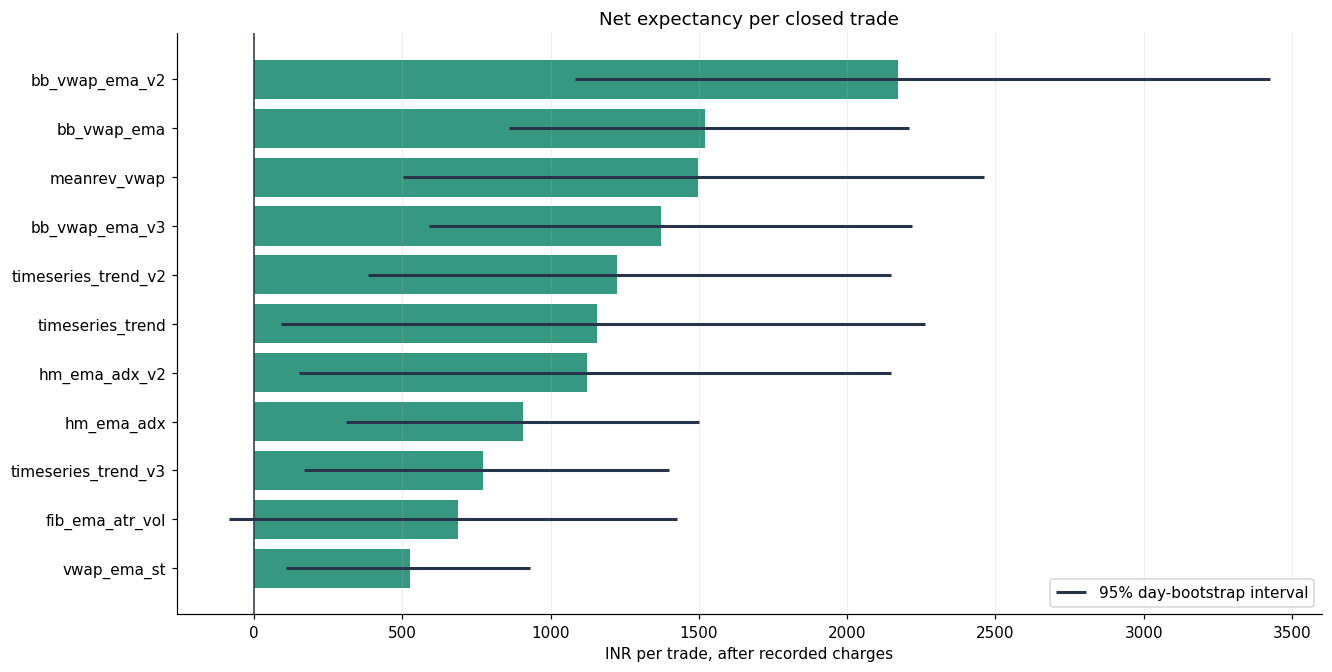

In [4]:
screen = summary[["trades", "win_rate", "loss_rate", "avg_win", "avg_loss", "expectancy", "expectancy_ci_low", "expectancy_ci_high", "profit_factor", "recent_30_expectancy"]].copy()
screen["decision"] = np.where(summary.expectancy_positive, "ACCEPT: positive expectancy", "REJECT: non-positive expectancy")
show_table(screen)
fig = expectancy_chart(summary)
if EXPORT:
    fig.savefig(FIGURE_DIR / "expectancy.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Edge: cumulative return vs number of trades
Click legend names to hide/show strategies; double-click to isolate one. All curves use net P&L and their own reported initial capital. Different trade counts and exposure mean this is not a like-for-like forward test.

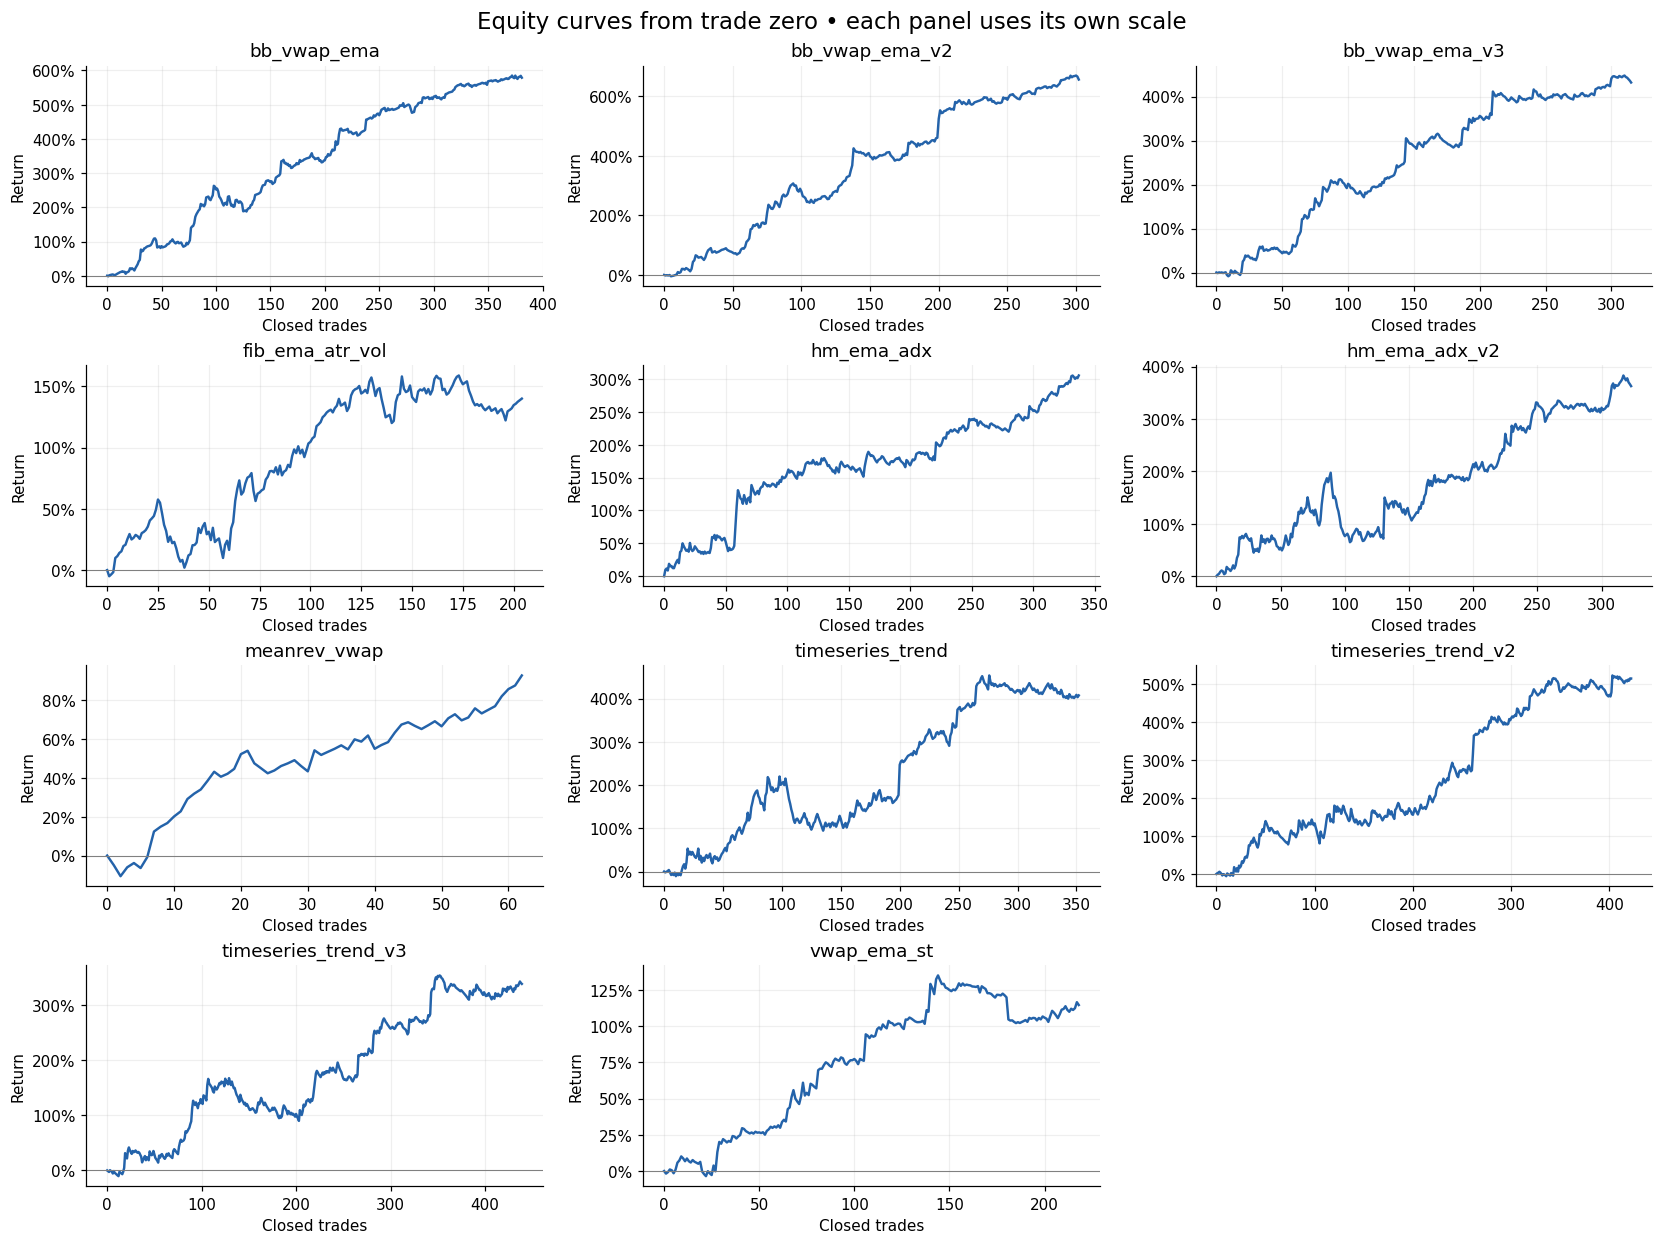

,net_pnl,gross_pnl,charges,total_return,max_trade_drawdown,max_daily_drawdown,max_loss_streak
strategy,,,,,,,
bb_vwap_ema_v2,"656,222.71","730,884.04","74,661.32",656.22%,-16.01%,-15.29%,6.00
bb_vwap_ema,"578,856.07","669,015.58","90,159.52",578.86%,-20.72%,-18.15%,6.00
meanrev_vwap,"92,881.09","103,682.62","10,801.54",92.88%,-10.65%,-10.65%,3.00
bb_vwap_ema_v3,"432,105.95","509,416.65","77,310.70",432.11%,-13.13%,-11.41%,12.00
timeseries_trend_v2,"515,781.10","617,265.64","101,484.54",515.78%,-25.85%,-23.71%,11.00
timeseries_trend,"407,470.87","488,456.48","80,985.61",407.47%,-39.21%,-38.93%,8.00
hm_ema_adx_v2,"362,735.66","438,337.85","75,602.19",362.74%,-44.56%,-42.54%,8.00
hm_ema_adx,"305,234.55","385,668.96","80,434.41",305.23%,-15.08%,-14.73%,6.00
timeseries_trend_v3,"338,687.40","441,951.24","103,263.83",338.69%,-28.99%,-28.99%,8.00


In [5]:
interactive_equity = equity_comparison(strategies)
interactive_equity.show(renderer="plotly_mimetype")
fig = equity_small_multiples(strategies)
if EXPORT:
    interactive_equity.write_html(FIGURE_DIR / "equity_comparison.html", include_plotlyjs=True)
    fig.savefig(FIGURE_DIR / "equity_by_trade.png", dpi=160, bbox_inches="tight")
plt.show()
show_table(summary[["net_pnl", "gross_pnl", "charges", "total_return", "max_trade_drawdown", "max_daily_drawdown", "max_loss_streak"]])

## Risk per trade and the screenshot

The screenshot supplies risk rows **0.25%, 0.5%, 1%, 1.5%, 2.5%, 4%** and win-rate columns **40%–90%**, but no definition of the percentages inside it. Its numbers are retained below **only as a reference**, not attributed to these strategies.

Our separate, editable simulation measures **the probability of reaching the configured return target before breaching the configured peak-to-trough drawdown limit, within the configured number of trades**. These are example assumptions, not inferred screenshot settings or provider payout rules.

Each path starts at equity 1 and updates as `equity *= max(0, 1 + risk_fraction * sampled_net_R)`. Target and drawdown checks occur after every trade; hitting either barrier ends that path. A drawdown breach takes precedence; a path hitting neither barrier is a timeout.

The observed-win-rate table resamples the strategy's full empirical net-R distribution. The win-rate grid varies the probability of winning while sampling the strategy's observed winning and losing R sizes separately, retaining the observed breakeven rate. It therefore shows sensitivity to hypothetical win rates, not validated improvement in the strategy.

Trades are sampled independently with replacement; streak dependence and regime shifts can make real risk worse. Historical net-R includes recorded charges; scaling it assumes costs and fills scale proportionally, ignores lot sizes, and is a research approximation. `monte_carlo_se` measures simulation noise only, not uncertainty in the historical sample. No risk level is automatically recommended.

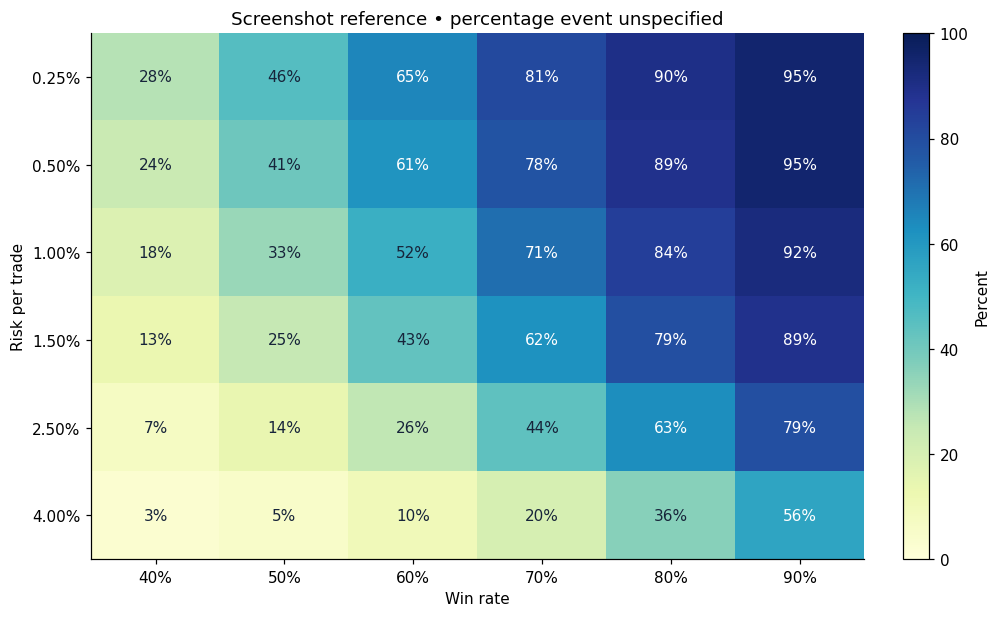

,trades,win_rate,median_risk_fraction,p95_risk_fraction,max_risk_fraction,risk_coverage,risk_fraction_coverage,mean_net_r
strategy,,,,,,,,
bb_vwap_ema_v2,302.00,62.91%,2.53%,11.15%,34.37%,100.00%,99.67%,0.17
bb_vwap_ema,381.00,73.23%,2.77%,10.76%,55.48%,100.00%,99.74%,0.12
meanrev_vwap,62.00,70.97%,1.92%,5.75%,8.73%,100.00%,100.00%,0.33
bb_vwap_ema_v3,315.00,48.89%,0.79%,3.02%,9.58%,100.00%,100.00%,0.37
timeseries_trend_v2,422.00,45.02%,1.54%,4.54%,9.33%,100.00%,100.00%,0.24
timeseries_trend,352.00,57.95%,2.05%,6.92%,22.04%,100.00%,100.00%,0.20
hm_ema_adx_v2,323.00,54.18%,2.84%,7.93%,10.68%,100.00%,98.76%,0.17
hm_ema_adx,337.00,48.96%,0.89%,3.47%,6.24%,100.00%,99.70%,0.28
timeseries_trend_v3,439.00,41.46%,1.01%,2.96%,9.17%,100.00%,100.00%,0.28


Simulation settings: SimulationConfig(target_return=0.1, max_drawdown=0.1, horizon_trades=100, paths=5000, seed=42)


In [6]:
fig = heatmap(SCREENSHOT_REFERENCE, "Screenshot reference • percentage event unspecified", fractions=False)
plt.show()
show_table(summary[["trades", "win_rate", "median_risk_fraction", "p95_risk_fraction", "max_risk_fraction", "risk_coverage", "risk_fraction_coverage", "mean_net_r"]])
print("Simulation settings:", SIMULATION)

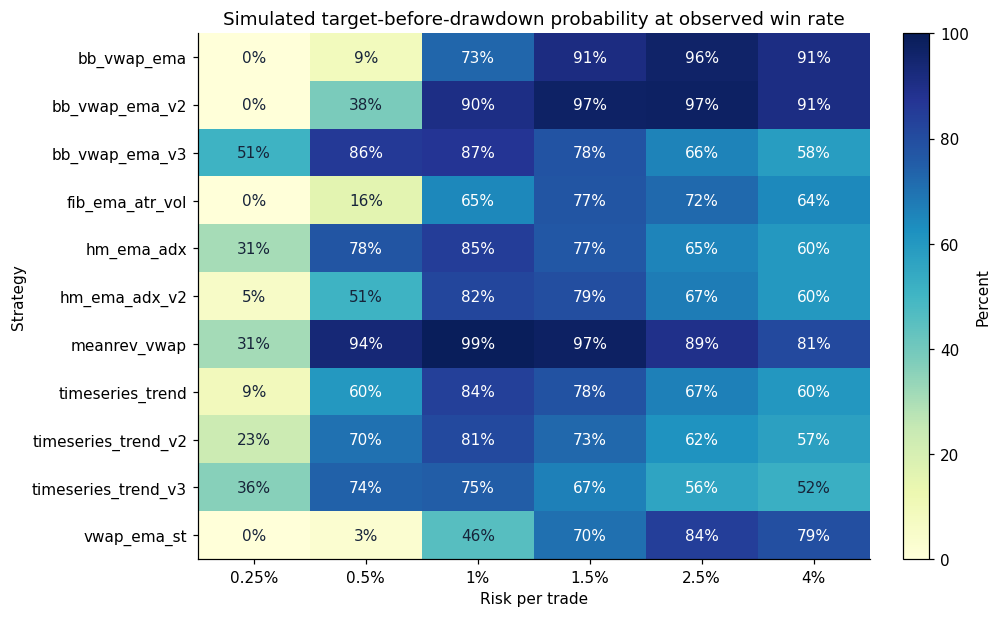

,strategy,risk_fraction,success_probability,drawdown_breach_probability,timeout_probability,monte_carlo_se
0,bb_vwap_ema,0.25%,0.00%,0.00%,100.00%,0.00%
1,bb_vwap_ema,0.50%,8.68%,0.00%,91.32%,0.40%
2,bb_vwap_ema,1.00%,72.76%,0.00%,27.24%,0.63%
3,bb_vwap_ema,1.50%,91.22%,0.14%,8.64%,0.40%
4,bb_vwap_ema,2.50%,96.32%,2.28%,1.40%,0.27%
5,bb_vwap_ema,4.00%,90.92%,9.06%,0.02%,0.41%
6,bb_vwap_ema_v2,0.25%,0.14%,0.00%,99.86%,0.05%
7,bb_vwap_ema_v2,0.50%,38.46%,0.00%,61.54%,0.69%
8,bb_vwap_ema_v2,1.00%,90.30%,0.02%,9.68%,0.42%
9,bb_vwap_ema_v2,1.50%,97.12%,0.12%,2.76%,0.24%


In [7]:
risk_tables = {name: strategy_risk_scenarios(d, SIMULATION) for name, d in strategies.items()}
risk_results = pd.concat(risk_tables, names=["strategy", "risk_fraction"]).reset_index()
probability = risk_results.pivot(index="strategy", columns="risk_fraction", values="success_probability")
fig = heatmap(probability, "Simulated target-before-drawdown probability at observed win rate", xlabel="Risk per trade", ylabel="Strategy")
if EXPORT:
    fig.savefig(FIGURE_DIR / "risk_probability.png", dpi=160, bbox_inches="tight")
plt.show()
show_table(risk_results)

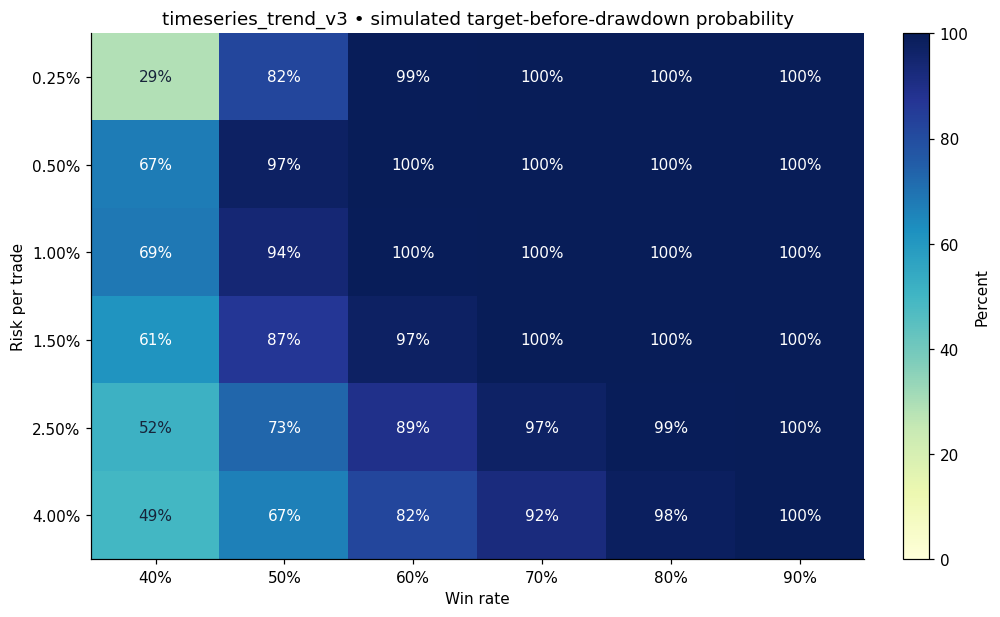

In [8]:
# Change this to inspect another strategy's win-rate sensitivity grid.
SELECTED_STRATEGY = "timeseries_trend_v3"
matrix = risk_win_matrix(strategies[SELECTED_STRATEGY], SIMULATION)
fig = heatmap(matrix, f"{SELECTED_STRATEGY} • simulated target-before-drawdown probability")
plt.show()

## 4. Return and drawdown vs days
Each notebook below contains the same definitions, its full daily history, monthly returns, drawdown episodes, trade diagnostics and risk scenarios.

In [9]:
display(Markdown("\n".join(f"- [{name}]({name}.ipynb)" for name in strategies)))

- [bb_vwap_ema](bb_vwap_ema.ipynb)
- [bb_vwap_ema_v2](bb_vwap_ema_v2.ipynb)
- [bb_vwap_ema_v3](bb_vwap_ema_v3.ipynb)
- [fib_ema_atr_vol](fib_ema_atr_vol.ipynb)
- [hm_ema_adx](hm_ema_adx.ipynb)
- [hm_ema_adx_v2](hm_ema_adx_v2.ipynb)
- [meanrev_vwap](meanrev_vwap.ipynb)
- [timeseries_trend](timeseries_trend.ipynb)
- [timeseries_trend_v2](timeseries_trend_v2.ipynb)
- [timeseries_trend_v3](timeseries_trend_v3.ipynb)
- [vwap_ema_st](vwap_ema_st.ipynb)

## Export results
CSV outputs retain full numeric precision. Re-run this notebook after replacing reports. Keep one bundle per strategy in `RAW_DIR`; ambiguous duplicates raise an error.

In [10]:
if EXPORT:
    summary.to_csv(OUTPUT_DIR / "strategy_summary.csv")
    screen.to_csv(OUTPUT_DIR / "expectancy_screen.csv")
    audit.to_csv(OUTPUT_DIR / "reconciliation.csv", index=False)
    risk_results.to_csv(OUTPUT_DIR / "risk_scenarios.csv", index=False)
    excluded.to_csv(OUTPUT_DIR / "excluded_orders.csv", index=False)
    chronology_issues.to_csv(OUTPUT_DIR / "chronology_issues.csv", index=False)
    print(f"Saved tables to {OUTPUT_DIR} and charts to {FIGURE_DIR}")

Saved tables to /home/amit/python/src/github.com/AppsByZubin/visualizer/data/processed/strategy_analysis and charts to /home/amit/python/src/github.com/AppsByZubin/visualizer/outputs/figures/strategy
